In [1]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt



In [2]:
counts_betaine = pd.read_csv('../output/gap_length_counts_betaine.csv')
counts_no_betaine = pd.read_csv('../output/gap_length_counts_no_betaine.csv')

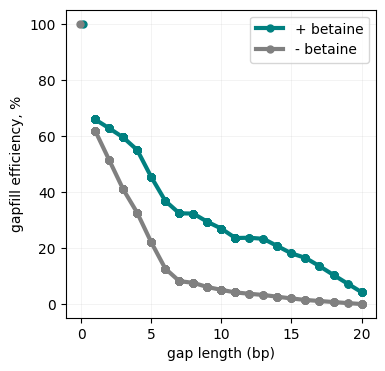

In [3]:
sample1 = 'HB betaine'
sample2 = 'HB'
merge = counts_betaine[['probe_idx','probe_barcode','name','counts_per_0bp','gap_length','count_0bp']].merge(counts_no_betaine[['probe_idx','probe_barcode','name','counts_per_0bp','gap_length','count_0bp']], on = ['probe_idx','name','probe_barcode','gap_length'], how='outer', suffixes=('_' + sample1,'_' + sample2))

min_0bp_counts = 50
merge = merge.loc[(merge['count_0bp_HB'] > min_0bp_counts) & (merge['count_0bp_HB betaine'] > min_0bp_counts), ].copy()

max_counts_per_0bp = 5
merge.loc[merge['counts_per_0bp_HB betaine'] > max_counts_per_0bp, 'counts_per_0bp_HB betaine'] = max_counts_per_0bp
merge.loc[merge['counts_per_0bp_HB'] > max_counts_per_0bp, 'counts_per_0bp_HB'] = max_counts_per_0bp

merge = merge.loc[merge['gap_length'] > 0].copy()

### fit loess to all points
fig,ax = plt.subplots(figsize=(4,4))
x = merge['gap_length']
y = 100 * merge['counts_per_0bp_' + sample1]

# Fit loess
loess_result_betaine = sm.nonparametric.lowess(y, x, frac=0.3, return_sorted=True)

x = merge['gap_length']
y = 100 * merge['counts_per_0bp_' + sample2]

# Fit loess
loess_result_no_betaine = sm.nonparametric.lowess(y, x, frac=0.3, return_sorted=True)

ax.plot(loess_result_betaine[:, 0], loess_result_betaine[:, 1], color='teal', linewidth=3,alpha=1, label='+ betaine', marker = 'o', markersize=5)
ax.plot(loess_result_no_betaine[:, 0], loess_result_no_betaine[:, 1], color='grey', linewidth=3, label='- betaine', marker = 'o', markersize=5)

ax.plot([0.1], [100], color='teal', linewidth=3, marker = 'o', markersize=5)
ax.plot([-0.1], [100], color='grey', linewidth=3, marker = 'o', markersize=5)

ax.set_xlabel('gap length (bp)', size=10)
ax.set_ylabel('gapfill efficiency, %', size=10)

ax.grid(alpha=0.2, linewidth=0.5)
ax.legend()
ax.set_ylim(-5,105)

plt.savefig('../plots/gap_length_betaine_comparison.pdf')